In [1]:

# Install langgraph and langchain if needed (uncomment when running locally)
# !pip install langgraph>=0.2.0 langchain langchain-openai

from typing import TypedDict, List, Optional, Literal, Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
import operator
import uuid


In [2]:

# Define the state using State object and reducers
class CustomerServiceState(TypedDict):
    messages: Annotated[list, add_messages]
    department: Optional[Literal["billing", "technical", "sales"]]
    user_id: str
    issue_id: Optional[str]
    user_name: Optional[str]
    issue_history: Annotated[List[str], operator.add]
    resolved: bool


In [3]:
# Define routing and department handlers
from langchain_core.messages import HumanMessage, AIMessage


# Router function determines department based on keywords and adds initial tasks
def route_customer(state: CustomerServiceState) -> CustomerServiceState:
    department = None
    ai_message = None

    if not state["messages"]:
        return state

    last_message = state["messages"][-1].content.lower()
    if any(word in last_message for word in ["bill", "payment", "charge"]):
        department = "billing"
        ai_message = AIMessage(content="I'll help you with your billing issue. Let me check your account.")
    elif any(word in last_message for word in ["broken", "error", "not working"]):
        department = "technical"
        ai_message = AIMessage(content="Let's troubleshoot your technical issue.")
    elif any(word in last_message for word in ["buy", "purchase", "upgrade"]):
        department = "sales"
        ai_message = AIMessage(content="I'd be happy to help with your purchase.")

    return {
        "messages": [ai_message],
        "department": department,
        "issue_id": str(uuid.uuid4()),
        "resolved": False,
    }


# Department handlers process and resolve issues
def handle_billing(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "billing-" + state["issue_id"]
    return {"messages": [AIMessage(content="Retrieved billing history: Last payment $99")], "resolved": True, "issue_history": [new_issues_id]}


def handle_technical(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "technical-" + state["issue_id"]
    return {"messages": [AIMessage(content="Diagnostics complete. No hardware issues detected.")], "resolved": True, "issue_history": [new_issues_id]}


def handle_sales(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "sales-" + state["issue_id"]
    return {"messages": [AIMessage(content="Products available: Premium Upgrade, Family Plan.")], "resolved": True, "issue_history": [new_issues_id]}

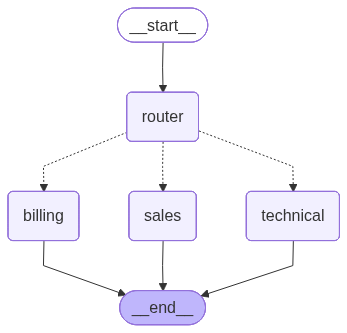

In [11]:
from IPython.display import Image


# Build the workflow
workflow = StateGraph(CustomerServiceState)
workflow.add_node("router", route_customer)
workflow.set_entry_point("router")


def next_step(state: CustomerServiceState):
    if state["resolved"]:
        return END
    return state["department"] or "router"

workflow.add_node("billing", handle_billing)
workflow.add_node("technical", handle_technical)
workflow.add_node("sales", handle_sales)

workflow.add_conditional_edges(
    "router",
    next_step,
    {
        # Mapping the output of route_decision to the next node name
        "billing": "billing",
        "technical": "technical",
        "sales": "sales",
    }
)
workflow.add_edge("billing", END)
workflow.add_edge("technical", END)
workflow.add_edge("sales", END)
memory = InMemorySaver()

app = workflow.compile(checkpointer=memory)

Image(app.get_graph().draw_mermaid_png())

In [12]:
print(workflow.add_conditional_edges.__doc__)

Add a conditional edge from the starting node to any number of destination nodes.

Args:
    source: The starting node. This conditional edge will run when
        exiting this node.
    path: The callable that determines the next
        node or nodes. If not specifying `path_map` it should return one or
        more nodes. If it returns END, the graph will stop execution.
    path_map: Optional mapping of paths to node
        names. If omitted the paths returned by `path` should be node names.

Returns:
    Self: The instance of the graph, allowing for method chaining.

Note: Without typehints on the `path` function's return value (e.g., `-> Literal["foo", "__end__"]:`)
    or a path_map, the graph visualization assumes the edge could transition to any node in the graph.




In [5]:
# Test the system with different queries

print("=== Demonstrating operator.add reducer\n")

# Billing query
state1 = CustomerServiceState(
    messages=[HumanMessage(content="My bill seems too high this month")],
    department=None,
    user_id="user123",
    user_name="John Doe",
    issue_history=[],
    resolved=False
)

config = {"configurable": {"thread_id": "user123"}}

result1 = app.invoke(state1, config=config)
print("Billing query result:")
print("Department:", result1['department'])
print("Final response:", result1['messages'][-1].content)
print("Customer issue history:", result1['issue_history'])
print()


result2 = app.invoke({"messages": [HumanMessage(content="My internet is not working properly")]}, config=config)
print("Technical query result:")
print("Department:", result2['department'])
print("Final response:", result2['messages'][-1].content)
print("Customer issue history:", result2['issue_history'])



=== Demonstrating operator.add reducer

Billing query result:
Department: billing
Final response: Retrieved billing history: Last payment $99
Customer issue history: ['billing-e4f639f6-82d2-4d3f-911a-fa41fc077360']

Technical query result:
Department: technical
Final response: Diagnostics complete. No hardware issues detected.
Customer issue history: ['billing-e4f639f6-82d2-4d3f-911a-fa41fc077360', 'technical-30027929-2627-47bb-a5fd-881366a5643a']
